# LEMON EEG Preprocessing Pipeline
## Based on DISCOVER-EEG (Gil Ávila et al., 2023, Scientific Data)

This notebook implements the full EEG preprocessing pipeline from the DISCOVER-EEG paper,
adapted for Python/MNE. The paper used this exact pipeline on the **MPI-Leipzig Mind-Brain-Body (LEMON)** dataset — the same dataset we have.

### Pipeline Steps (in order):
1. **Load raw data** — BrainVision format (.vhdr)
2. **Inspect raw data** — channels, sampling rate, events
3. **Set channel types & montage** — mark VEOG, assign electrode positions
4. **Plot raw data** — visual inspection
5. **Line noise removal** — remove 50 Hz power line interference
6. **High-pass filter** — remove slow drifts (transition band 0.25–0.75 Hz)
7. **Resample to 250 Hz** — match our migraine dataset sampling rate
8. **Bad channel detection & rejection** — flat, noisy, or uncorrelated channels
9. **Re-reference to average** — reconstruct FCz reference channel
10. **ICA + ICLabel** — decompose signals, auto-reject Muscle/Eye components
11. **Interpolate removed channels** — spherical spline interpolation
12. **Bad time segment removal** — reject high-variance segments
13. **Epoch into 2-second windows** — 50% overlap, reject discontinuous epochs
14. **Save preprocessed data** — for downstream analysis

### Why 250 Hz?
Our migraine labeled dataset (Chamanzar et al.) is recorded at 256 Hz and commonly resampled to 250 Hz.
To combine LEMON (healthy controls) with migraine data for classification, both must share the same sampling rate.

### Key difference from paper:
- Paper uses **MATLAB/EEGLAB**; we use **Python/MNE-Python** with equivalent functions
- Paper uses **CleanLine** for line noise; we use MNE's `notch_filter` (spectrum_fit method)
- Paper uses **EEGLAB ICLabel**; we use **mne-icalabel** (same underlying model)

## Step 0: Import Required Libraries

We need:
- **MNE-Python** (`mne`): The core EEG processing library — Python equivalent of EEGLAB
- **mne_icalabel**: Python port of ICLabel — classifies ICA components as Brain/Muscle/Eye/etc.
- **NumPy**: Numerical operations on arrays
- **Matplotlib**: Plotting and visualization
- **os, glob**: File system navigation to find all subject folders

In [2]:
# ============================================================
# STEP 0: Import all required libraries
# ============================================================
import mne
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import warnings
import time

# MNE-ICALabel: Python equivalent of EEGLAB's ICLabel plugin
# It classifies each ICA component into categories:
# Brain, Muscle, Eye, Heart, Line Noise, Channel Noise, Other
from mne_icalabel import label_components

# PyTorch: used internally by mne-icalabel for ICLabel inference
import torch

# Print versions for reproducibility
print(f'MNE version: {mne.__version__}')
print(f'NumPy version: {np.__version__}')
print(f'PyTorch version: {torch.__version__}')

# ============================================================
# GPU CONFIGURATION
# ============================================================
print(f'\n{"="*50}')
print('GPU STATUS')
print(f'{"="*50}')

# Check PyTorch CUDA (used by ICLabel)
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    # Some PyTorch builds expose total_memory, others may use total_mem.
    total_bytes = getattr(props, 'total_memory', getattr(props, 'total_mem', None))
    gpu_mem = total_bytes / 1024**3 if total_bytes is not None else float('nan')
    print(f'PyTorch CUDA:  AVAILABLE')
    print(f'  Device:      {gpu_name}')
    if np.isnan(gpu_mem):
        print('  Memory:      unavailable (property missing in this torch build)')
    else:
        print(f'  Memory:      {gpu_mem:.1f} GB')
    print(f'  PyTorch default device: cuda')
    torch.set_default_device('cuda')
else:
    print(f'PyTorch CUDA:  NOT AVAILABLE (ICLabel will run on CPU)')

# Check MNE CUDA support (uses CuPy for FIR filtering acceleration)
try:
    import cupy
    mne.cuda.init_cuda(verbose=False)
    mne.utils.set_config('MNE_USE_CUDA', 'true', set_env=True)
    print(f'MNE CUDA:      AVAILABLE (CuPy {cupy.__version__})')
    print(f'  -> Filtering & resampling will use GPU')
    MNE_CUDA = True
except ImportError:
    print(f'MNE CUDA:      NOT AVAILABLE (CuPy not installed)')
    print(f'  -> Filtering & resampling will use CPU')
    print(f'  -> To enable: pip install cupy-cuda12x  (match your CUDA version)')
    MNE_CUDA = False

print(f'{"="*50}')

# Set MNE log level to WARNING to reduce verbose output
mne.set_log_level('WARNING')

# Set random seed for reproducibility (ICA has random initialization)
RANDOM_STATE = 42

MNE version: 1.11.0
NumPy version: 2.4.2
PyTorch version: 2.10.0+cu126

GPU STATUS
PyTorch CUDA:  AVAILABLE
  Device:      NVIDIA GeForce GTX 1650
  Memory:      4.0 GB
  PyTorch default device: cuda
MNE CUDA:      AVAILABLE (CuPy 14.0.1)
  -> Filtering & resampling will use GPU


## Step 1: Define Data Paths and Configuration

The LEMON dataset is organized in BIDS-like format:
```
EEG_MPILMBB_LEMON/
  EEG_Raw_BIDS_ID/
    sub-010002/
      RSEEG/
        sub-010002.vhdr   <-- BrainVision header (we load this)
        sub-010002.eeg    <-- Binary data
        sub-010002.vmrk   <-- Event markers
    sub-010003/
      ...
```

**Key facts about LEMON recordings:**
- **62 channels**: 61 scalp EEG + 1 VEOG (below right eye)
- **Sampling rate**: 2500 Hz (we'll downsample to 250 Hz)
- **Reference**: FCz (will be reconstructed when we re-reference)
- **Ground**: Sternum
- **Events**: S210 = eyes closed, S200 = eyes open (interleaved 1-min blocks)

In [3]:
# ============================================================
# STEP 1: Define paths and pipeline parameters
# ============================================================

# Root directory for the LEMON dataset
LEMON_DIR = r'G:\Study\FYDP-I_Personalized-Migraine-Mitigation-Via-Binaural-Beats\EEG_MPILMBB_LEMON\EEG_Raw_BIDS_ID'

# Output directory for preprocessed files
OUTPUT_DIR = r'G:\Study\FYDP-I_Personalized-Migraine-Mitigation-Via-Binaural-Beats\data\LEMON_preprocessed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- Pipeline Parameters (matching the DISCOVER-EEG paper) ----

# Target sampling rate (must match migraine dataset)
TARGET_SFREQ = 250  # Hz

# Line noise frequency (50 Hz in Europe where LEMON was recorded)
LINE_NOISE_FREQ = 50  # Hz

# High-pass filter: paper uses transition band 0.25-0.75 Hz
# In MNE, l_freq=0.5 with default FIR gives similar transition band
HIGHPASS_FREQ = 0.5  # Hz (passband edge)

# Bad channel detection thresholds (matching paper defaults)
FLATLINE_THRESHOLD = 5  # seconds - channel flat > this = bad
ZSCORE_THRESHOLD = 5    # z-scored variance threshold (5 = catches outliers, not normal high-variance channels)
MIN_CORRELATION = 0.55  # >= 0.50 as required; 0.55 is conservative but fair

# ICA-ICLabel rejection threshold
# Paper: reject components with >80% probability of Muscle OR Eye
IC_REJECTION_THRESHOLD = 0.80

# Epoch parameters
EPOCH_DURATION = 2.0  # seconds
EPOCH_OVERLAP = 0.5   # 50% overlap -> step = 1.0 second

# Get list of all subjects
subject_dirs = sorted(glob.glob(os.path.join(LEMON_DIR, 'sub-*')))
print(f'Found {len(subject_dirs)} subjects in LEMON dataset')
print(f'First 5: {[os.path.basename(d) for d in subject_dirs[:5]]}')
print(f'Last 5:  {[os.path.basename(d) for d in subject_dirs[-5:]]}')

Found 220 subjects in LEMON dataset
First 5: ['sub-010002', 'sub-010003', 'sub-010004', 'sub-010005', 'sub-010006']
Last 5:  ['sub-010316', 'sub-010317', 'sub-010318', 'sub-010319', 'sub-010321']


## Step 2: Load Raw EEG Data (Single Subject Demo)

We'll first demonstrate the entire pipeline on **one subject** so you can see every step clearly.
Then we'll run it on all subjects.

**`mne.io.read_raw_brainvision()`** loads BrainVision format files:
- Reads the `.vhdr` header file (which points to `.eeg` data and `.vmrk` markers)
- `preload=True` loads all data into RAM — required for filtering, resampling, and ICA
- Returns a `Raw` object containing the continuous EEG data + metadata

In [4]:
# ============================================================
# STEP 2: Load raw EEG data for one demo subject
# ============================================================

# Pick the first subject for demonstration
demo_subject = subject_dirs[0]
subject_id = os.path.basename(demo_subject)
vhdr_file = os.path.join(demo_subject, 'RSEEG', f'{subject_id}.vhdr')

print(f'Loading: {subject_id}')
print(f'File: {vhdr_file}')

# Load raw BrainVision data
# preload=True : loads all data into memory (required for in-place operations)
raw = mne.io.read_raw_brainvision(vhdr_file, preload=True, verbose=False)

print(f'\n{"="*50}')
print(f'Raw data loaded successfully!')
print(f'{"="*50}')

Loading: sub-010002
File: G:\Study\FYDP-I_Personalized-Migraine-Mitigation-Via-Binaural-Beats\EEG_MPILMBB_LEMON\EEG_Raw_BIDS_ID\sub-010002\RSEEG\sub-010002.vhdr

Raw data loaded successfully!


## Step 3: Inspect Raw Data Structure

The `raw.info` object is a metadata dictionary. Understanding it is critical:
- **`sfreq`**: Sampling frequency in Hz (should be 2500 Hz for LEMON)
- **`nchan`**: Number of channels (should be 62)
- **`ch_names`**: List of channel name strings
- **`highpass` / `lowpass`**: Hardware filter settings during recording

We also check **events** — the markers S210 (eyes closed) and S200 (eyes open) that tell us
which time segments correspond to which condition.

In [5]:
# ============================================================
# STEP 3: Inspect the raw data structure
# ============================================================

print('=' * 60)
print('RAW DATA PROPERTIES')
print('=' * 60)
print(f'Sampling frequency:  {raw.info["sfreq"]} Hz')
print(f'Number of channels:  {raw.info["nchan"]}')
print(f'Duration:            {raw.times[-1]:.1f} seconds ({raw.times[-1]/60:.1f} minutes)')
print(f'Number of timepoints: {raw.n_times}')
print(f'Data shape:          ({raw.info["nchan"]}, {raw.n_times})')
print(f'Hardware highpass:   {raw.info["highpass"]} Hz')
print(f'Hardware lowpass:    {raw.info["lowpass"]} Hz')

# List all channel names
print(f'\nChannel names ({len(raw.ch_names)}):')
for i, ch in enumerate(raw.ch_names):
    print(f'  Ch{i+1:2d}: {ch}', end='')
    if (i + 1) % 6 == 0:
        print()
print()

# Extract events from annotations
events, event_id = mne.events_from_annotations(raw, verbose=False)
print(f'\nEvent types found: {event_id}')
print(f'Total events: {len(events)}')
for name, eid in event_id.items():
    count = np.sum(events[:, 2] == eid)
    print(f'  "{name}": {count} occurrences')

RAW DATA PROPERTIES
Sampling frequency:  2500.0 Hz
Number of channels:  62
Duration:            1022.0 seconds (17.0 minutes)
Number of timepoints: 2555000
Data shape:          (62, 2555000)
Hardware highpass:   0.015915494309189534 Hz
Hardware lowpass:    1000.0 Hz

Channel names (62):
  Ch 1: Fp1  Ch 2: Fp2  Ch 3: F7  Ch 4: F3  Ch 5: Fz  Ch 6: F4
  Ch 7: F8  Ch 8: FC5  Ch 9: FC1  Ch10: FC2  Ch11: FC6  Ch12: T7
  Ch13: C3  Ch14: Cz  Ch15: C4  Ch16: T8  Ch17: VEOG  Ch18: CP5
  Ch19: CP1  Ch20: CP2  Ch21: CP6  Ch22: AFz  Ch23: P7  Ch24: P3
  Ch25: Pz  Ch26: P4  Ch27: P8  Ch28: PO9  Ch29: O1  Ch30: Oz
  Ch31: O2  Ch32: PO10  Ch33: AF7  Ch34: AF3  Ch35: AF4  Ch36: AF8
  Ch37: F5  Ch38: F1  Ch39: F2  Ch40: F6  Ch41: FT7  Ch42: FC3
  Ch43: FC4  Ch44: FT8  Ch45: C5  Ch46: C1  Ch47: C2  Ch48: C6
  Ch49: TP7  Ch50: CP3  Ch51: CPz  Ch52: CP4  Ch53: TP8  Ch54: P5
  Ch55: P1  Ch56: P2  Ch57: P6  Ch58: PO7  Ch59: PO3  Ch60: POz
  Ch61: PO4  Ch62: PO8

Event types found: {np.str_('Comment/no USB Co

## Step 4: Set Channel Types and Montage

### What is a montage?
A **montage** defines the **3D positions** of each electrode on the scalp. This is needed for:
- Topographic maps (plotting brain activity on a head shape)
- Spherical spline interpolation (Step 11)
- ICA spatial patterns visualization

### What we do here:
1. **Mark VEOG as EOG channel** — VEOG (vertical electrooculogram, below right eye) records eye blinks. It's NOT an EEG channel.
2. **Apply `standard_1005` montage** — LEMON electrodes follow the 10-10 system. MNE's `standard_1005` has positions for all.
3. **Add FCz back** — FCz was the recording reference (all zeros). We add it so we can reconstruct it during re-referencing.

In [6]:

# - ICA will use EOG to help identify blink components
#   - EOG channels are excluded from EEG analyses
raw.set_channel_types({'VEOG': 'eog'})
print('VEOG channel type set to eog')
# mne.add_reference_channels() adds it as a flat (all-zeros) channel.
# Only add FCz if it is not already present (some LEMON BIDS files include it)
if 'FCz' not in raw.ch_names:
    raw = mne.add_reference_channels(raw, ref_channels=['FCz'], copy=False)
    print('FCz reference channel added back (flat, will be reconstructed in re-referencing)')
else:
    print('FCz already present in channel list (no need to add)')

montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage, on_missing='warn', verbose=False)
print('standard_1005 montage applied')

# Verify
eeg_channels = mne.pick_types(raw.info, eeg=True, eog=False)
print(f'\nChannel summary:')
print(f'  EEG channels: {len(eeg_channels)} (including reconstructed FCz)')
print(f'  EOG channels: {len(mne.pick_types(raw.info, eog=True))}')
print(f'  Total:        {raw.info["nchan"]}')

VEOG channel type set to eog
FCz reference channel added back (flat, will be reconstructed in re-referencing)
standard_1005 montage applied

Channel summary:
  EEG channels: 62 (including reconstructed FCz)
  EOG channels: 1
  Total:        63


## Step 5: Plot Raw Data — Power Spectral Density

Before any preprocessing, let's look at the **Power Spectral Density (PSD)**:
- You should see a **50 Hz spike** (power line noise) — we'll remove this next
- You should see an **alpha peak (~10 Hz)** in posterior channels — this is real brain activity
- You should see **1/f falloff** (power decreases with frequency) — this is normal

> At 2500 Hz sampling, we can see frequencies up to 1250 Hz (Nyquist), but EEG of interest is below 100 Hz.

Computing PSD on EEG channels (excluding reconstructed FCz placeholder)...


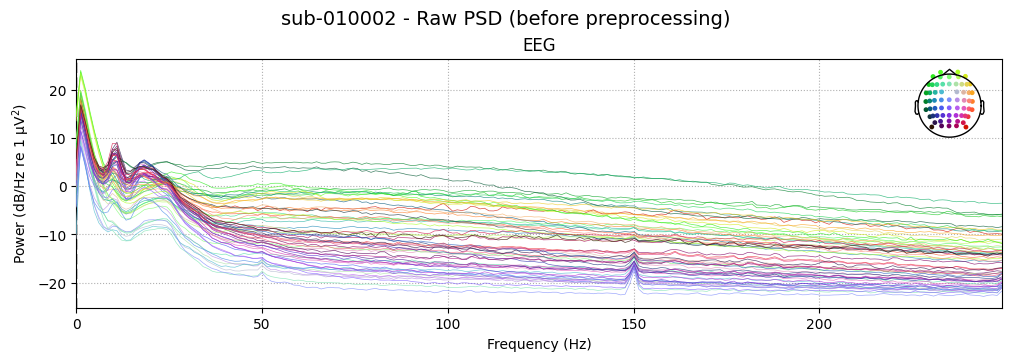

Look for the 50 Hz spike (power line noise) and alpha peak around 10 Hz


In [ ]:
# ============================================================
# STEP 5: Plot raw PSD (before any preprocessing)
# ============================================================

print('Computing PSD on EEG channels (excluding reconstructed FCz placeholder)...')
picks_psd = [ch for ch in raw.ch_names if ch != 'FCz']

# PSD shows how much power exists at each frequency.
# fmax=250: only show up to 250 Hz (rest is just noise)
fig = raw.compute_psd(fmax=250, picks=picks_psd, verbose=False).plot(show=False)
fig.suptitle(f'{subject_id} - Raw PSD (before preprocessing)', fontsize=14)
plt.savefig(os.path.join(OUTPUT_DIR, f'{subject_id}_raw_psd.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Look for the 50 Hz spike (power line noise) and alpha peak around 10 Hz')

## Step 6: Line Noise Removal (50 Hz)

### Paper's approach: CleanLine (multi-taper regression)
### Our approach: `raw.notch_filter()` with `method='spectrum_fit'`

**What is line noise?**
Power lines emit electromagnetic radiation at their operating frequency (50 Hz in Europe, 60 Hz in USA).
This creates a sharp spike at 50 Hz (and harmonics: 100 Hz) in the EEG spectrum.

**Why not just use a simple notch filter?**
A simple notch filter creates a "gap" in the spectrum, which can distort nearby frequencies.
The `spectrum_fit` method (similar to CleanLine) uses **regression** to estimate the sinusoidal
noise component and subtract it — preserving the spectrum shape around 50 Hz.

**Parameters:**
- `freqs=[50, 100]`: Remove fundamental + first harmonic
- `method='spectrum_fit'`: Regression-based removal (similar to CleanLine)

Removing line noise at 50 Hz and harmonic at 100 Hz...
Line noise removed


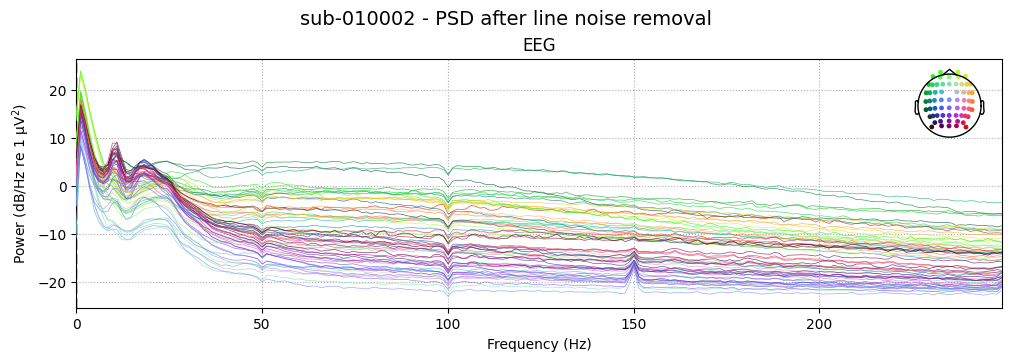

Compare with previous PSD - the 50 Hz spike should be gone!


In [ ]:

print(f'Removing line noise at {LINE_NOISE_FREQ} Hz and harmonic at {LINE_NOISE_FREQ * 2} Hz...')
raw.notch_filter(
    freqs=[LINE_NOISE_FREQ, LINE_NOISE_FREQ * 2], 
    method='spectrum_fit', # Regression-based 
    verbose=False
)

print('Line noise removed')

# Plot PSD after notch to verify 50 Hz is gone
picks_psd = [ch for ch in raw.ch_names if ch != 'FCz']
fig = raw.compute_psd(fmax=250, picks=picks_psd, verbose=False).plot(show=False)
fig.suptitle(f'{subject_id} - PSD after line noise removal', fontsize=14)
plt.savefig(os.path.join(OUTPUT_DIR, f'{subject_id}_psd_after_notch.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Compare with previous PSD - the 50 Hz spike should be gone!')

## Step 7: High-Pass Filter (0.5 Hz)

### Paper's approach: Transition band 0.25-0.75 Hz (via clean_rawdata)
### Our approach: `raw.filter(l_freq=0.5)` — FIR filter with passband edge at 0.5 Hz

**What does a high-pass filter do?**
It removes all frequencies **below** the cutoff, keeping everything above.

**Why do we need it?**
Raw EEG contains **slow drifts** caused by:
- Electrode impedance changes
- Skin potential changes (sweating)
- Breathing artifacts
- DC offset drift

These are very low frequency (<0.5 Hz) and mask the real brain signals.

**MNE's `filter()` function:**
- Uses **FIR (Finite Impulse Response)** filter by default
- `l_freq=0.5` sets the **passband edge** (everything above passes through)
- `h_freq=None` means no low-pass filter yet (handled during resampling)

In [ ]:

print(f'Applying high-pass filter at {HIGHPASS_FREQ} Hz...')
print(f'  This removes slow drifts (breathing, electrode drift, DC offset)')
print(f'  Brain signals of interest (delta: 1-4 Hz and above) are preserved')
if MNE_CUDA:
    print(f'  Using GPU-accelerated filtering (CuPy)')

raw.filter(
    l_freq=HIGHPASS_FREQ,  # 0.5 Hz -passband edge (keep everything above)
    h_freq=None,          
    fir_design='firwin',   # Standard FIR filter design
    n_jobs='cuda' if MNE_CUDA else 1,
    verbose=False
)

print(f'High-pass filter applied at {HIGHPASS_FREQ} Hz')

Applying high-pass filter at 0.5 Hz...
  This removes slow drifts (breathing, electrode drift, DC offset)
  Brain signals of interest (delta: 1-4 Hz and above) are preserved
  Using GPU-accelerated filtering (CuPy)
High-pass filter applied at 0.5 Hz


## Step 8: Resample to 250 Hz

### Why resample?
- LEMON was recorded at **2500 Hz** — much higher than needed for EEG analysis
- Our migraine dataset is at **250 Hz**
- To combine both datasets, they **must** share the same sampling rate
- Lower sampling rate = smaller files, faster processing

### How does `raw.resample()` work internally?
1. **Anti-aliasing low-pass filter** — auto-applies a low-pass at `new_sfreq / 2` (125 Hz)
2. **Decimation** — keeps every Nth sample (N = 2500/250 = 10)
3. Result: 10x fewer time points, frequencies up to 125 Hz preserved

### Nyquist theorem
If sampling rate is 250 Hz, the highest representable frequency is 125 Hz (= 250/2).
Anything above would "alias". The anti-aliasing filter prevents this.

### `npad='auto'`
Pads signal edges to reduce filter boundary effects during resampling.

In [5]:
# ============================================================
# STEP 8: Resample from 2500 Hz to 250 Hz
# ============================================================

original_sfreq = raw.info['sfreq']
original_n_times = raw.n_times

print(f'BEFORE resampling:')
print(f'  Sampling rate: {original_sfreq} Hz')
print(f'  Timepoints:    {original_n_times}')
print(f'  Duration:      {raw.times[-1]:.1f} seconds')
print(f'  Nyquist freq:  {original_sfreq / 2} Hz')

# Resample to 250 Hz
# MNE automatically applies an anti-aliasing low-pass filter before decimating.
# npad='auto' pads signal edges to reduce artifacts from the anti-aliasing filter.
raw.resample(
    sfreq=TARGET_SFREQ,  # 250 Hz
    npad='auto',         
    n_jobs='cuda' if MNE_CUDA else 1,
    verbose=False
)

print(f'\nAFTER resampling:')
print(f'  Sampling rate: {raw.info["sfreq"]} Hz')
print(f'  Timepoints:    {raw.n_times}')
print(f'  Duration:      {raw.times[-1]:.1f} seconds (unchanged - same duration!)')
print(f'  Nyquist freq:  {raw.info["sfreq"] / 2} Hz')
print(f'  Decimation factor: {original_sfreq / TARGET_SFREQ:.0f}x')
print(f'  Data reduction: {original_n_times} -> {raw.n_times} points ({raw.n_times/original_n_times*100:.1f}%)')

BEFORE resampling:
  Sampling rate: 2500.0 Hz
  Timepoints:    2555000
  Duration:      1022.0 seconds
  Nyquist freq:  1250.0 Hz

AFTER resampling:
  Sampling rate: 250.0 Hz
  Timepoints:    255500
  Duration:      1022.0 seconds (unchanged - same duration!)
  Nyquist freq:  125.0 Hz
  Decimation factor: 10x
  Data reduction: 2555000 -> 255500 points (10.0%)


## Step 9: Verify Resampling — PSD Comparison

Let's verify that resampling preserved the EEG signal properly:
- Frequencies up to **125 Hz** (new Nyquist) should look the same
- The 50 Hz line noise should still be gone
- The alpha peak around 10 Hz should still be visible
- Maximum visible frequency is now 125 Hz (was 1250 Hz)

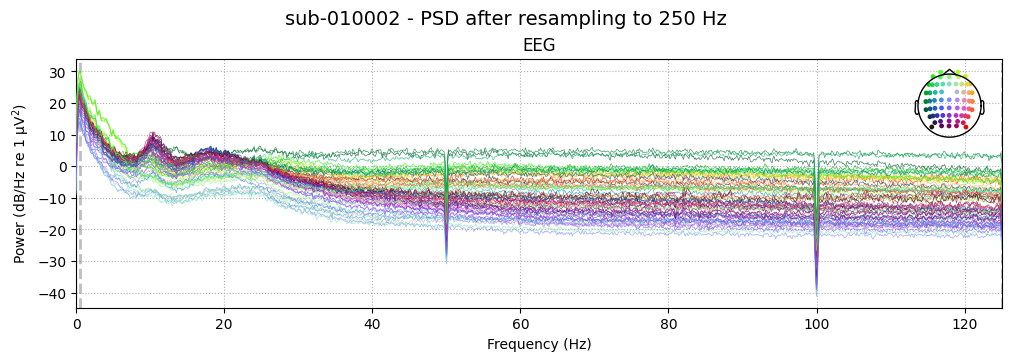

PSD verified - frequency content preserved up to 125 Hz (Nyquist)


In [10]:
# ============================================================
# STEP 9: Verify resampling with PSD plot
# ============================================================

picks_psd = [ch for ch in raw.ch_names if ch != 'FCz']
fig = raw.compute_psd(fmax=125, picks=picks_psd, verbose=False).plot(show=False)
fig.suptitle(f'{subject_id} - PSD after resampling to {TARGET_SFREQ} Hz', fontsize=14)
plt.savefig(os.path.join(OUTPUT_DIR, f'{subject_id}_psd_after_resample.png'), dpi=100, bbox_inches='tight')
plt.show()
print(f'PSD verified - frequency content preserved up to {TARGET_SFREQ // 2} Hz (Nyquist)')

## Step 10: Bad Channel Detection and Rejection

### Paper's criteria (clean_rawdata defaults):
A channel is marked **bad** if **any** of these are true:
1. **Flatline**: Channel is flat (zero variance) for more than **5 seconds**
2. **Noise-to-signal ratio**: Z-scored noise ratio exceeds **4** standard deviations
3. **Low correlation**: Channel cannot be predicted from neighboring channels at least **80% of the time**

### Our implementation:
MNE doesn't have `clean_rawdata` built-in, so we implement equivalent criteria:
1. **Flat channel detection** — check if channel has near-zero peak-to-peak amplitude in any 5s window
2. **High noise detection** — check if channel has abnormally high variance (z-score > 4)
3. **Low correlation detection** — check correlation with neighboring channels in sliding windows

Bad channels are **removed** from the data (not interpolated yet — that comes after ICA).

**Paper reports:** ~1-2 channels rejected per recording (~2-3%)

In [ ]:
def detect_bad_channels(raw, random_state=42, include_ransac=True):
    import mne
    import warnings

    try:
        from pyprep.find_noisy_channels import NoisyChannels
    except ImportError as exc:
        raise ImportError(
            "PyPREP is required for Step 10. Install it with: pip install pyprep"
        ) from exc

    # Work on EEG only and exclude FCz (original recording reference) which is flat and will be reconstructed in re-referencing 
    picks_eeg = mne.pick_types(raw.info, eeg=True, eog=False, exclude=[])
    eeg_names_all = [raw.ch_names[p] for p in picks_eeg]
    eeg_names = [ch for ch in eeg_names_all if ch != 'FCz']

    raw_prep = raw.copy().pick_channels(eeg_names, ordered=True)

    # PyPREP applies robust multi-criterion bad-channel checks.
    # these are built into the NoisyChannels class and can be accessed via
    # its attributes after running the find_bad_by_* methods.
    noisy = NoisyChannels(raw_prep, random_state=random_state)
    noisy.find_bad_by_nan_flat()
    noisy.find_bad_by_deviation()
    noisy.find_bad_by_hfnoise()
    noisy.find_bad_by_correlation()

    ransac_used = False
    if include_ransac:
        try:
            noisy.find_bad_by_ransac()
            ransac_used = True
        except Exception as exc:
            warnings.warn(
                f"PyPREP RANSAC failed ({type(exc).__name__}: {exc}). Continuing without RANSAC.",
                RuntimeWarning,
            )

    bad_channels = sorted(set(noisy.get_bads()))

    # Build per-channel reason text from available PyPREP result attributes.
    reason_sources = [
        ('bad_by_nan', 'NaN'),
        ('bad_by_flat', 'flatline'),
        ('bad_by_deviation', 'deviation'),
        ('bad_by_hf_noise', 'high-frequency noise'),
        ('bad_by_hfnoise', 'high-frequency noise'),
        ('bad_by_correlation', 'low correlation'),
        ('bad_by_ransac', 'RANSAC prediction mismatch'),
        ('bad_by_SNR', 'low SNR'),
        ('bad_by_dropout', 'dropout'),
    ]

    reasons = {}
    for ch in bad_channels:
        hits = []
        for attr_name, label in reason_sources:
            flagged = getattr(noisy, attr_name, None)
            if flagged is not None and ch in flagged:
                hits.append(label)
        if hits:
            reasons[ch] = ', '.join(sorted(set(hits)))
        else:
            reasons[ch] = 'flagged by PyPREP (multi-criterion)'

    return bad_channels, reasons, ransac_used


print('Detecting bad channels with PyPREP (clean_rawdata-style logic)...')
print('  Criteria: NaN/flatline, deviation, high-frequency noise, correlation')
print('  + RANSAC consistency check (enabled with automatic fallback)')
print('  (FCz excluded - it is the recording reference electrode)')

bad_chs, bad_reasons, ransac_used = detect_bad_channels(
    raw, random_state=RANDOM_STATE, include_ransac=True
)

if ransac_used:
    print('  RANSAC status: used successfully')
else:
    print('  RANSAC status: skipped due to runtime issue (fallback active)')

print(f'\nResult: {len(bad_chs)} bad channel(s) detected')
for ch in bad_chs:
    print(f'  - {ch}: {bad_reasons[ch]}')

raw.info['bads'] = bad_chs
n_eeg_total = len(mne.pick_types(raw.info, eeg=True, eog=False))
print(f'\n(Paper reports: ~1-2 bad channels per recording, ~2-3%)')
print(f'We found {len(bad_chs)}/{n_eeg_total} ({len(bad_chs)/n_eeg_total*100:.1f}%)')

Detecting bad channels with PyPREP (clean_rawdata-style logic)...
  Criteria: NaN/flatline, deviation, high-frequency noise, correlation
  + RANSAC consistency check (enabled with automatic fallback)
  (FCz excluded - it is the recording reference electrode)
  RANSAC status: skipped due to runtime issue (fallback active)

Result: 0 bad channel(s) detected

(Paper reports: ~1-2 bad channels per recording, ~2-3%)
We found 0/62 (0.0%)


C:\Users\milon\AppData\Local\Temp\ipykernel_9500\3577942338.py:32: RuntimeWarning: PyPREP RANSAC failed (ValueError: Found NaN in channel positions. Did you supply a montage for the raw data?). Continuing without RANSAC.
  warnings.warn(


## Step 11: Re-Reference to Average

### What is re-referencing?
Every EEG channel measures voltage **relative to a reference electrode**. LEMON used **FCz** as reference.
The choice of reference affects the signal shape.

### Why average reference?
- **Average reference** subtracts the mean of all channels from each channel at each time point
- Minimizes the influence of any single electrode
- Closest approximation to a "reference-free" recording
- Standard in modern EEG research (recommended by paper)

### Reconstructing FCz:
When we set the average reference, FCz gets reconstructed. Before re-referencing, FCz was all zeros
(it was the reference). After average re-referencing, it becomes the negative of the average of all
other channels at the original reference position.

In [12]:
# ============================================================
# STEP 11: Re-reference to average
# ============================================================

# Drop bad channels before re-referencing
# (they would contaminate the average reference if included)
dropped_bad_channels = list(raw.info['bads'])
if dropped_bad_channels:
    print(f'Dropping {len(dropped_bad_channels)} bad channels before re-referencing: {dropped_bad_channels}')
    raw_clean = raw.copy().drop_channels(dropped_bad_channels)
else:
    raw_clean = raw.copy()
    print('No bad channels to drop')

# Apply average reference
# projection=False: apply directly (not as a projector)
# Two effects:
#   1. Subtracts mean of all channels from each channel at each timepoint
#   2. Reconstructs FCz (previously all zeros)
raw_clean.set_eeg_reference(ref_channels='average', projection=False, verbose=False)

print(f'Average reference applied')
print(f'  Active EEG channels: {len(mne.pick_types(raw_clean.info, eeg=True, eog=False))}')
print(f'  FCz is now a real channel (reconstructed from average reference)')

No bad channels to drop
Average reference applied
  Active EEG channels: 62
  FCz is now a real channel (reconstructed from average reference)


## Step 12: ICA + ICLabel — Automatic Artifact Component Rejection

### What is ICA?
**Independent Component Analysis** decomposes multi-channel EEG into **independent components (ICs)**.
Each IC is a spatial pattern + time course. Ideally:
- Some ICs capture **brain activity** (distributed, smooth scalp patterns)
- Some ICs capture **eye blinks** (strong frontal pattern, spiky time course)
- Some ICs capture **muscle activity** (high-frequency, peripheral pattern)
- Some ICs capture **heartbeat** (regular, widespread pattern)

### What is ICLabel?
A deep learning classifier trained on thousands of manually labeled ICs. For each IC it outputs
**probabilities** for 7 categories: Brain, Muscle, Eye, Heart, Line Noise, Channel Noise, Other.

### Paper's rejection rule:
Remove components where **P(Muscle) > 80% OR P(Eye) > 80%**

### Why Infomax ICA?
The paper uses `runica` (Infomax algorithm). In MNE: `method='infomax'` with `extended=True`.

### Why after re-referencing?
ICA works better on re-referenced data because average referencing reduces rank by 1 and equalizes offset.

In [13]:
# ============================================================
# STEP 12a: ICA decomposition
# ============================================================

n_eeg_channels = len(mne.pick_types(raw_clean.info, eeg=True, eog=False))
n_components = n_eeg_channels - 1  # -1 for rank deficiency from average reference

print(f'Running ICA decomposition...')
print(f'  Number of EEG channels: {n_eeg_channels}')
print(f'  Number of ICA components: {n_components}')
print(f'  Method: Infomax (same as paper runica)')
print(f'  This may take a few minutes...')

# Create ICA object
# method='infomax': same algorithm as EEGLAB's runica
# extended=True: better at separating sub-Gaussian sources
# random_state: for reproducibility
ica = mne.preprocessing.ICA(
    n_components=n_components,
    method='infomax',
    fit_params=dict(extended=True),
    random_state=RANDOM_STATE,
    max_iter='auto',
    verbose=False
)

# Fit ICA on EEG channels only
ica.fit(raw_clean, picks='eeg', verbose=False)
print(f'ICA decomposition complete - {ica.n_components_} components extracted')

Running ICA decomposition...
  Number of EEG channels: 62
  Number of ICA components: 61
  Method: Infomax (same as paper runica)
  This may take a few minutes...
ICA decomposition complete - 61 components extracted


In [14]:
# ============================================================
# STEP 12b: ICLabel classification and rejection
# ============================================================

# Use ICLabel to classify each component
# Returns probabilities for: Brain, Muscle, Eye, Heart, Line Noise, Channel Noise, Other
ic_labels = label_components(raw_clean, ica, method='iclabel')

print(f'\nICLabel classification results:')
print(f'{"Component":<12} {"Label":<15} {"Confidence":<12} {"Action"}')
print('-' * 55)

# Identify components to reject (paper: Muscle OR Eye > 80%)
components_to_reject = []
for i in range(ica.n_components_):
    label = ic_labels['labels'][i]
    probs = ic_labels['y_pred_proba'][i]
    confidence = max(probs)
    
    # ICLabel categories: brain, muscle artifact, eye blink, heart beat,
    #                     line noise, channel noise, other
    muscle_prob = probs[1]  # muscle artifact
    eye_prob = probs[2]     # eye blink
    
    should_reject = (muscle_prob > IC_REJECTION_THRESHOLD) or (eye_prob > IC_REJECTION_THRESHOLD)
    action = 'REJECT' if should_reject else 'keep'
    
    if should_reject:
        components_to_reject.append(i)
    
    # Print rejected + first 5 kept
    if should_reject or i < 5:
        print(f'  IC{i:03d}      {label:<15} {confidence:.2%}        {action}')

print(f'\n{"="*55}')
print(f'Components to reject: {len(components_to_reject)} / {ica.n_components_} ({len(components_to_reject)/ica.n_components_*100:.1f}%)')
print(f'Rejected indices: {components_to_reject}')
print(f'(Paper reports: ~6-9 ICs rejected, ~11-15%)')

C:\Users\milon\AppData\Local\Temp\ipykernel_9500\187708675.py:7: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_clean, ica, method='iclabel')


ValueError: Montage is not set. Please set the montage to provide the electrode positions.

In [ ]:
# ============================================================
# STEP 12c: Apply ICA - remove artifact components
# ============================================================

# Mark components for exclusion
ica.exclude = components_to_reject

# Apply ICA: subtract artifact components from the data
# Mathematically: X_clean = A_keep @ S_keep
# (reconstruct from all ICs EXCEPT the excluded ones)
raw_clean = ica.apply(raw_clean, verbose=False)

print(f'ICA applied - {len(components_to_reject)} artifact components removed')
print(f'  Eye blink and muscle artifacts are now removed')
print(f'  Brain components are preserved')

## Step 13: Interpolate Removed Bad Channels

### What is interpolation?
We removed bad channels in Step 10. Now we **reconstruct** them using data from neighbors.

### Why spherical spline interpolation?
- Models the scalp as a sphere and fits a smooth surface through the good channels
- Bad channel's value is estimated from this surface
- Standard method (Perrin et al., 1989), same as paper's `pop_interp()`

### Why after ICA?
- Bad channels would contaminate ICA if included
- ICA needs clean data for good source separation
- After ICA, we interpolate to restore the full montage

### Why do we need all channels back?
- ML models expect **fixed-size input** (same channels for all subjects)
- Our migraine classification needs consistent channel count

In [ ]:
# ============================================================
# STEP 13: Interpolate bad channels using spherical splines
# ============================================================

if dropped_bad_channels:
    print(f'Interpolating {len(dropped_bad_channels)} bad channel(s): {dropped_bad_channels}')
    
    # Add bad channels back as flat channels
    for ch_name in dropped_bad_channels:
        if ch_name not in raw_clean.ch_names:
            raw_clean = mne.add_reference_channels(raw_clean, ref_channels=[ch_name], verbose=False)
    
    # Mark them as bad so interpolation knows which to fix
    raw_clean.info['bads'] = dropped_bad_channels
    
    # Ensure montage is set for interpolation positions
    montage = mne.channels.make_standard_montage('standard_1005')
    raw_clean.set_montage(montage, on_missing='warn', verbose=False)
    
    # Interpolate using spherical splines (same as paper's pop_interp)
    raw_clean.interpolate_bads(reset_bads=True, verbose=False)
    
    print(f'Bad channels interpolated using spherical splines')
    print(f'  All channels restored - total: {len(mne.pick_types(raw_clean.info, eeg=True, eog=False))} EEG channels')
else:
    print('No bad channels to interpolate - all channels are clean!')
    print(f'  Total EEG channels: {len(mne.pick_types(raw_clean.info, eeg=True, eog=False))}')

## Step 14: Bad Time Segment Rejection

### Paper's approach: Artifact Subspace Reconstruction (ASR)
ASR identifies **time segments** where signal variance is abnormally high compared to a clean baseline.

### Paper's parameters:
- Calibration: segments where <7.5% of channels are noisy (RMS std > 5.5)
- Rejection: segments with >20x higher variance than calibration

### Our implementation:
MNE doesn't have built-in ASR, so we use **amplitude-based** annotation:
1. Check peak-to-peak amplitude in sliding windows
2. If any channel exceeds threshold in a window, annotate as BAD
3. These annotations cause overlapping epochs to be rejected in Step 15

**Paper reports:** ~30 seconds rejected per recording (~6-7%)

In [ ]:
# ============================================================
# STEP 14: Bad time segment detection and annotation
# ============================================================

def annotate_bad_segments(raw, threshold_uv=150, window_s=0.5):
    """
    Detect bad time segments based on peak-to-peak amplitude.
    Similar to ASR - flags segments with abnormally high amplitude.
    
    Parameters:
    -----------
    raw : mne.io.Raw
        The preprocessed raw data
    threshold_uv : float
        Peak-to-peak amplitude threshold in microvolts (default: 150)
    window_s : float
        Window size in seconds for checking amplitude (default: 0.5)
        
    Returns:
    --------
    n_bad_seconds : float - total bad segment duration
    """
    sfreq = raw.info['sfreq']
    window_samples = int(window_s * sfreq)
    picks_eeg = mne.pick_types(raw.info, eeg=True, eog=False)
    data = raw.get_data(picks=picks_eeg) * 1e6  # Convert V to uV
    
    n_windows = data.shape[1] // window_samples
    bad_annotations = []
    
    for w in range(n_windows):
        start = w * window_samples
        end = start + window_samples
        window_data = data[:, start:end]
        ptp = np.ptp(window_data, axis=1)  # peak-to-peak per channel
        
        if np.any(ptp > threshold_uv):
            onset = start / sfreq
            bad_annotations.append((onset, window_s, 'BAD_artifact'))
    
    if bad_annotations:
        onsets = [a[0] for a in bad_annotations]
        durations = [a[1] for a in bad_annotations]
        descriptions = [a[2] for a in bad_annotations]
        bad_annot = mne.Annotations(onset=onsets, duration=durations, description=descriptions)
        raw.set_annotations(raw.annotations + bad_annot)
    
    return len(bad_annotations) * window_s


print('Detecting bad time segments (high-amplitude artifacts)...')
print('  Catches: movement, electrode pops, muscle bursts')
print(f'  Threshold: 150 uV peak-to-peak in any channel')

total_duration = raw_clean.times[-1]
bad_seconds = annotate_bad_segments(raw_clean, threshold_uv=150, window_s=0.5)

print(f'\nResult:')
print(f'  Total recording: {total_duration:.1f} s')
print(f'  Bad segments:    {bad_seconds:.1f} s ({bad_seconds/total_duration*100:.1f}%)')
print(f'  Clean remaining: {total_duration - bad_seconds:.1f} s ({(total_duration-bad_seconds)/total_duration*100:.1f}%)')
print(f'\n(Paper reports: ~30s rejected per recording, ~6-7%)')

## Step 15: Segment into 2-Second Epochs with 50% Overlap

### What is epoching?
Cutting continuous EEG into **fixed-length segments** (epochs). Each epoch becomes one data sample.

### Paper's parameters:
- **Duration**: 2 seconds
- **Overlap**: 50% (each epoch shares 1 second with the previous one)
- **Rejection**: epochs containing a discontinuity (from bad segments) are rejected

### Why 2 seconds?
- **Frequency resolution**: 1/2s = 0.5 Hz — enough to distinguish frequency bins
- **Stationarity**: shorter segments are more likely stationary
- **Reliability**: good for power spectral and connectivity estimates

### Why 50% overlap?
- Mitigates signal loss at epoch boundaries (due to windowing/tapering)
- More epochs = better statistics

### `make_fixed_length_epochs()`:
1. Cuts continuous data into chunks
2. Epochs overlapping BAD annotations are automatically dropped
3. Returns Epochs object: shape = (n_epochs, n_channels, n_times)

In [ ]:
# ============================================================
# STEP 15: Epoch the data - 2-second windows with 50% overlap
# ============================================================

# Drop the EOG channel - keep only EEG for brain analysis
raw_eeg = raw_clean.copy().pick('eeg')
print(f'Kept {len(raw_eeg.ch_names)} EEG channels (dropped EOG)')

# Create fixed-length epochs
# duration=2.0: each epoch is 2 seconds
# overlap=1.0: 50% overlap (2s epoch, 1s step)
# reject_by_annotation=True: auto-reject epochs overlapping BAD_ annotations
epochs = mne.make_fixed_length_epochs(
    raw_eeg,
    duration=EPOCH_DURATION,                        # 2.0 seconds
    overlap=EPOCH_DURATION * EPOCH_OVERLAP,          # 1.0 second (50% overlap)
    preload=True,
    verbose=False
)

print(f'\nEpoching results:')
print(f'  Epoch duration:  {EPOCH_DURATION} seconds')
print(f'  Overlap:         {EPOCH_OVERLAP*100:.0f}% ({EPOCH_DURATION * EPOCH_OVERLAP}s)')
print(f'  Step size:       {EPOCH_DURATION * (1 - EPOCH_OVERLAP)}s')
print(f'  Total epochs:    {len(epochs)}')
print(f'  Epoch shape:     {epochs.get_data().shape}')
print(f'    = ({len(epochs)} epochs, {epochs.get_data().shape[1]} channels, {epochs.get_data().shape[2]} timepoints)')
print(f'    = {epochs.get_data().shape[2]} samples = {EPOCH_DURATION}s x {TARGET_SFREQ} Hz = {int(EPOCH_DURATION * TARGET_SFREQ)}')
print(f'\n(Paper reports: ~444 clean 2-second epochs from 8 minutes)')

## Step 16: Epoch Amplitude Rejection (Final QC)

Even after ICA and bad segment annotation, some epochs may have residual artifacts.
We apply a **peak-to-peak amplitude threshold** as a final safety net.

`reject=dict(eeg=150e-6)` means:
- For each epoch, check if **any EEG channel** has peak-to-peak > 150 uV
- If yes, drop that epoch

In [ ]:
# ============================================================
# STEP 16: Reject remaining bad epochs by amplitude
# ============================================================

n_before = len(epochs)

# Peak-to-peak rejection: 150 uV max per channel per epoch
epochs.drop_bad(reject=dict(eeg=150e-6), verbose=False)

n_after = len(epochs)
n_dropped = n_before - n_after

print(f'Epoch rejection (150 uV peak-to-peak):')
print(f'  Before: {n_before} epochs')
print(f'  After:  {n_after} epochs')
print(f'  Dropped: {n_dropped} ({n_dropped/n_before*100:.1f}%)')

# Final data shape
data = epochs.get_data()
print(f'\n{"="*50}')
print(f'FINAL PREPROCESSED DATA')
print(f'{"="*50}')
print(f'  Shape:         {data.shape}')
print(f'  = {data.shape[0]} epochs x {data.shape[1]} channels x {data.shape[2]} timepoints')
print(f'  Sampling rate: {epochs.info["sfreq"]} Hz')
print(f'  Epoch length:  {EPOCH_DURATION}s ({int(EPOCH_DURATION * TARGET_SFREQ)} samples)')
print(f'  Channels:      {epochs.ch_names[:5]} ... {epochs.ch_names[-3:]}')

## Step 17: Save Preprocessed Data

We save in two formats:
1. **MNE `.fif` format** — preserves all metadata (channel info, montage, events)
2. **NumPy `.npy` format** — raw array, easy to combine with migraine data

### Data shape for downstream ML:
```
(n_epochs, n_channels, n_timepoints) = (N, 62, 500)
```
- **N**: varies per subject (~400-500 clean epochs)
- **62**: EEG channels (61 original + FCz reconstructed)
- **500**: 2 seconds x 250 Hz

In [ ]:
# ============================================================
# STEP 17: Save preprocessed data for this demo subject
# ============================================================

# Save as MNE Epochs format (.fif) - preserves all metadata
fif_path = os.path.join(OUTPUT_DIR, f'{subject_id}-epo.fif')
epochs.save(fif_path, overwrite=True, verbose=False)
print(f'Saved MNE epochs: {fif_path}')

# Save as NumPy array (.npy) - easy for ML pipelines
npy_path = os.path.join(OUTPUT_DIR, f'{subject_id}_epochs.npy')
np.save(npy_path, epochs.get_data())
print(f'Saved NumPy array: {npy_path}')
print(f'  Shape: {epochs.get_data().shape}')

# Save channel names for reference
ch_names_path = os.path.join(OUTPUT_DIR, 'channel_names.txt')
with open(ch_names_path, 'w') as f:
    f.write('\n'.join(epochs.ch_names))
print(f'Saved channel names: {ch_names_path}')

# Verify saved file
loaded = mne.read_epochs(fif_path, verbose=False)
print(f'\nVerification (loaded back):')
print(f'  Shape: {loaded.get_data().shape}')
print(f'  Sfreq: {loaded.info["sfreq"]} Hz')
print(f'  Channels: {len(loaded.ch_names)}')
del loaded

---
## Step 18: Full Batch Processing — All LEMON Subjects

Now we wrap everything above into a single function and run on **ALL** subjects.

**Output per subject:**
- `sub-XXXXXX-epo.fif` — MNE epochs file
- `sub-XXXXXX_epochs.npy` — NumPy array (n_epochs, 62, 500)

**Estimated time:** ~2-5 minutes per subject

In [ ]:
# ============================================================
# STEP 18: Full preprocessing function for batch processing
# Self-contained so single-subject demo steps are optional
# ============================================================

def _ensure_batch_helpers():
    """Create helper functions if Step 10/14 were not run."""
    global detect_bad_channels, annotate_bad_segments

    if 'detect_bad_channels' not in globals():
        def detect_bad_channels(raw, random_state=42, include_ransac=True):
            import mne
            import warnings

            try:
                from pyprep.find_noisy_channels import NoisyChannels
            except ImportError as exc:
                raise ImportError(
                    "PyPREP is required for bad-channel detection. Install it with: pip install pyprep"
                ) from exc

            picks_eeg = mne.pick_types(raw.info, eeg=True, eog=False, exclude=[])
            eeg_names_all = [raw.ch_names[p] for p in picks_eeg]
            eeg_names = [ch for ch in eeg_names_all if ch != 'FCz']
            raw_prep = raw.copy().pick_channels(eeg_names, ordered=True)

            noisy = NoisyChannels(raw_prep, random_state=random_state)
            noisy.find_bad_by_nan_flat()
            noisy.find_bad_by_deviation()
            noisy.find_bad_by_hfnoise()
            noisy.find_bad_by_correlation()

            ransac_used = False
            if include_ransac:
                try:
                    noisy.find_bad_by_ransac()
                    ransac_used = True
                except Exception as exc:
                    warnings.warn(
                        f"PyPREP RANSAC failed ({type(exc).__name__}: {exc}). Continuing without RANSAC.",
                        RuntimeWarning,
                    )

            bad_channels = sorted(set(noisy.get_bads()))
            reasons = {ch: 'flagged by PyPREP (multi-criterion)' for ch in bad_channels}
            return bad_channels, reasons, ransac_used

    if 'annotate_bad_segments' not in globals():
        def annotate_bad_segments(raw, threshold_uv=150, window_s=0.5):
            import mne
            import numpy as np

            sfreq = raw.info['sfreq']
            window_samples = int(window_s * sfreq)
            picks_eeg = mne.pick_types(raw.info, eeg=True, eog=False)
            data = raw.get_data(picks=picks_eeg) * 1e6

            n_windows = data.shape[1] // window_samples
            bad_annotations = []

            for w in range(n_windows):
                start = w * window_samples
                end = start + window_samples
                window_data = data[:, start:end]
                ptp = np.ptp(window_data, axis=1)
                if np.any(ptp > threshold_uv):
                    onset = start / sfreq
                    bad_annotations.append((onset, window_s, 'BAD_artifact'))

            if bad_annotations:
                onsets = [a[0] for a in bad_annotations]
                durations = [a[1] for a in bad_annotations]
                descriptions = [a[2] for a in bad_annotations]
                bad_annot = mne.Annotations(onset=onsets, duration=durations, description=descriptions)
                raw.set_annotations(raw.annotations + bad_annot)

            return len(bad_annotations) * window_s


_ensure_batch_helpers()


def preprocess_lemon_subject(vhdr_file, output_dir,
                              target_sfreq=250,
                              line_noise_freq=50,
                              highpass_freq=0.5,
                              ic_threshold=0.80,
                              epoch_duration=2.0,
                              epoch_overlap_frac=0.5,
                              amplitude_reject_uv=150e-6,
                              random_state=42,
                              use_cuda=False):
    """
    Full DISCOVER-EEG preprocessing pipeline for one LEMON subject.
    
    Parameters
    ----------
    vhdr_file : str - Path to .vhdr file
    output_dir : str - Directory to save results
    target_sfreq : float - Target sampling rate (250 Hz)
    line_noise_freq : float - Power line frequency (50 Hz)
    highpass_freq : float - High-pass cutoff (0.5 Hz)
    ic_threshold : float - ICLabel rejection threshold (0.80)
    epoch_duration : float - Epoch length in seconds (2.0)
    epoch_overlap_frac : float - Overlap fraction (0.5)
    amplitude_reject_uv : float - Peak-to-peak threshold in V (150e-6)
    random_state : int - Random seed (42)
    use_cuda : bool - Use GPU for filtering/resampling if available
    
    Returns
    -------
    dict with preprocessing summary
    """
    n_jobs = 'cuda' if use_cuda else 1
    subject_id = os.path.basename(os.path.dirname(os.path.dirname(vhdr_file)))
    result = {'subject': subject_id, 'status': 'success'}
    
    try:
        # --- LOAD ---
        raw = mne.io.read_raw_brainvision(vhdr_file, preload=True, verbose=False)
        result['duration_s'] = raw.times[-1]
        
        # --- CHANNEL TYPES + MONTAGE ---
        raw.set_channel_types({'VEOG': 'eog'})
        if 'FCz' not in raw.ch_names:
            raw = mne.add_reference_channels(raw, ref_channels=['FCz'], verbose=False)
        montage = mne.channels.make_standard_montage('standard_1005')
        raw.set_montage(montage, on_missing='warn', verbose=False)
        
        # --- LINE NOISE REMOVAL ---
        raw.notch_filter(
            freqs=[line_noise_freq, line_noise_freq * 2],
            method='spectrum_fit', verbose=False
        )
        
        # --- HIGH-PASS FILTER ---
        raw.filter(l_freq=highpass_freq, h_freq=None, n_jobs=n_jobs, verbose=False)
        
        # --- RESAMPLE ---
        raw.resample(sfreq=target_sfreq, npad='auto', n_jobs=n_jobs, verbose=False)
        
        # --- BAD CHANNEL DETECTION ---
        bad_chs, _, _ = detect_bad_channels(raw)
        raw.info['bads'] = bad_chs
        result['n_bad_channels'] = len(bad_chs)
        result['bad_channels'] = bad_chs
        
        # --- DROP BAD CHANNELS ---
        dropped = list(raw.info['bads'])
        if dropped:
            raw_clean = raw.copy().drop_channels(dropped)
        else:
            raw_clean = raw.copy()
        
        # --- RE-REFERENCE TO AVERAGE ---
        raw_clean.set_eeg_reference(ref_channels='average', projection=False, verbose=False)
        
        # --- ICA + ICLabel ---
        n_eeg = len(mne.pick_types(raw_clean.info, eeg=True, eog=False))
        n_components = n_eeg - 1
        
        ica = mne.preprocessing.ICA(
            n_components=n_components, method='infomax',
            fit_params=dict(extended=True),
            random_state=random_state, max_iter='auto', verbose=False
        )
        ica.fit(raw_clean, picks='eeg', verbose=False)
        
        ic_labels = label_components(raw_clean, ica, method='iclabel')
        reject_ics = []
        for i in range(ica.n_components_):
            probs = ic_labels['y_pred_proba'][i]
            if probs[1] > ic_threshold or probs[2] > ic_threshold:
                reject_ics.append(i)
        
        ica.exclude = reject_ics
        raw_clean = ica.apply(raw_clean, verbose=False)
        result['n_rejected_ics'] = len(reject_ics)
        result['n_total_ics'] = ica.n_components_
        
        # --- INTERPOLATE BAD CHANNELS ---
        if dropped:
            for ch in dropped:
                if ch not in raw_clean.ch_names:
                    raw_clean = mne.add_reference_channels(raw_clean, ref_channels=[ch], verbose=False)
            raw_clean.info['bads'] = dropped
            montage = mne.channels.make_standard_montage('standard_1005')
            raw_clean.set_montage(montage, on_missing='warn', verbose=False)
            raw_clean.interpolate_bads(reset_bads=True, verbose=False)
        
        # --- BAD SEGMENT ANNOTATION ---
        bad_s = annotate_bad_segments(raw_clean, threshold_uv=150, window_s=0.5)
        result['bad_segments_s'] = bad_s
        
        # --- EPOCHING ---
        raw_eeg = raw_clean.copy().pick('eeg')
        epochs = mne.make_fixed_length_epochs(
            raw_eeg, duration=epoch_duration,
            overlap=epoch_duration * epoch_overlap_frac,
            preload=True, verbose=False
        )
        
        # --- EPOCH REJECTION ---
        n_before = len(epochs)
        epochs.drop_bad(reject=dict(eeg=amplitude_reject_uv), verbose=False)
        result['n_epochs_before'] = n_before
        result['n_epochs_after'] = len(epochs)
        result['epoch_shape'] = epochs.get_data().shape
        
        # --- SAVE ---
        fif_path = os.path.join(output_dir, f'{subject_id}-epo.fif')
        epochs.save(fif_path, overwrite=True, verbose=False)
        
        npy_path = os.path.join(output_dir, f'{subject_id}_epochs.npy')
        np.save(npy_path, epochs.get_data())
        
        ch_path = os.path.join(output_dir, 'channel_names.txt')
        if not os.path.exists(ch_path):
            with open(ch_path, 'w') as f:
                f.write('\n'.join(epochs.ch_names))
        
        del raw, raw_clean, raw_eeg, ica, epochs
        
    except Exception as e:
        result['status'] = 'failed'
        result['error'] = str(e)
    
    return result

In [ ]:
# ============================================================
# STEP 18b: Process ALL subjects
# ============================================================

print(f'{"="*70}')
print(f'LEMON DATASET - FULL BATCH PREPROCESSING')
print(f'{"="*70}')
print(f'Subjects to process: {len(subject_dirs)}')
print(f'Output directory: {OUTPUT_DIR}')
print(f'Target sampling rate: {TARGET_SFREQ} Hz')
print(f'GPU acceleration: {"YES (CuPy)" if MNE_CUDA else "NO"}')
print(f'{"="*70}\n')

results = []
start_time = time.time()

for idx, subject_dir in enumerate(subject_dirs):
    subject_id = os.path.basename(subject_dir)
    vhdr_file = os.path.join(subject_dir, 'RSEEG', f'{subject_id}.vhdr')
    
    # Skip if already preprocessed
    output_npy = os.path.join(OUTPUT_DIR, f'{subject_id}_epochs.npy')
    if os.path.exists(output_npy):
        print(f'[{idx+1:3d}/{len(subject_dirs)}] {subject_id} - SKIPPED (already done)')
        continue
    
    # Check if .vhdr file exists
    if not os.path.exists(vhdr_file):
        print(f'[{idx+1:3d}/{len(subject_dirs)}] {subject_id} - SKIPPED (no .vhdr file)')
        results.append({'subject': subject_id, 'status': 'missing_file'})
        continue
    
    t0 = time.time()
    print(f'[{idx+1:3d}/{len(subject_dirs)}] {subject_id} - Processing...', end=' ', flush=True)
    
    result = preprocess_lemon_subject(
        vhdr_file=vhdr_file,
        output_dir=OUTPUT_DIR,
        target_sfreq=TARGET_SFREQ,
        line_noise_freq=LINE_NOISE_FREQ,
        highpass_freq=HIGHPASS_FREQ,
        ic_threshold=IC_REJECTION_THRESHOLD,
        epoch_duration=EPOCH_DURATION,
        epoch_overlap_frac=EPOCH_OVERLAP,
        random_state=RANDOM_STATE,
        use_cuda=MNE_CUDA
    )
    
    elapsed = time.time() - t0
    results.append(result)
    
    if result['status'] == 'success':
        shape = result['epoch_shape']
        print(f'Done {elapsed:.1f}s | {shape[0]} epochs | {result["n_bad_channels"]} bad ch | {result["n_rejected_ics"]} ICs rejected')
    else:
        print(f'FAILED: {result.get("error", "unknown")}')

total_time = time.time() - start_time
print(f'\n{"="*70}')
print(f'BATCH COMPLETE')
print(f'{"="*70}')
n_success = sum(1 for r in results if r.get('status') == 'success')
n_failed = sum(1 for r in results if r.get('status') == 'failed')
print(f'  Total time: {total_time/60:.1f} minutes')
print(f'  Successful: {n_success}/{len(results)}')
print(f'  Failed:     {n_failed}/{len(results)}')

In [ ]:
# ============================================================
# STEP 18c: Summary statistics
# ============================================================
import pandas as pd

successful = [r for r in results if r.get('status') == 'success']

if successful:
    df = pd.DataFrame(successful)
    
    print(f'{"="*60}')
    print(f'PREPROCESSING SUMMARY ({len(successful)} subjects)')
    print(f'{"="*60}')
    
    print(f'\nBad channels rejected per subject:')
    print(f'  Mean +/- SD: {df["n_bad_channels"].mean():.1f} +/- {df["n_bad_channels"].std():.1f}')
    print(f'  Range:       {df["n_bad_channels"].min()} - {df["n_bad_channels"].max()}')
    print(f'  (Paper: 1 +/- 2 channels)')
    
    print(f'\nICA components rejected per subject:')
    print(f'  Mean +/- SD: {df["n_rejected_ics"].mean():.1f} +/- {df["n_rejected_ics"].std():.1f}')
    print(f'  Range:       {df["n_rejected_ics"].min()} - {df["n_rejected_ics"].max()}')
    print(f'  (Paper: 6 +/- 3 components)')
    
    print(f'\nBad segments per subject:')
    print(f'  Mean +/- SD: {df["bad_segments_s"].mean():.1f} +/- {df["bad_segments_s"].std():.1f} seconds')
    print(f'  (Paper: 32 +/- 42 seconds)')
    
    n_epochs = [r['epoch_shape'][0] for r in successful]
    print(f'\nClean epochs per subject:')
    print(f'  Mean +/- SD: {np.mean(n_epochs):.0f} +/- {np.std(n_epochs):.0f}')
    print(f'  Range:       {np.min(n_epochs)} - {np.max(n_epochs)}')
    print(f'  (Paper: ~444 epochs)')
    
    summary_path = os.path.join(OUTPUT_DIR, 'preprocessing_summary.csv')
    df.to_csv(summary_path, index=False)
    print(f'\nSummary saved to: {summary_path}')
else:
    print('No results to summarize yet. Run batch processing first.')

---
## Pipeline Complete!

### What we implemented (matching the DISCOVER-EEG paper):
| Step | Operation | MNE Function | Paper Equivalent |
|------|-----------|-------------|------------------|
| 0 | Import libraries | `import mne` | MATLAB/EEGLAB |
| 1 | Configuration | Parameters dict | `params.json` |
| 2 | Load data | `read_raw_brainvision()` | `pop_loadbv()` |
| 3 | Inspect data | `raw.info` | — |
| 4 | Channel types + montage | `set_channel_types()`, `set_montage()` | BIDS metadata |
| 5 | Plot raw PSD | `compute_psd().plot()` | — |
| 6 | Line noise removal | `notch_filter(method='spectrum_fit')` | `pop_cleanline()` |
| 7 | High-pass filter | `raw.filter(l_freq=0.5)` | `pop_clean_rawdata()` |
| 8 | Resample to 250 Hz | `raw.resample(250)` | Optional downsampling |
| 9 | Verify resampling | PSD comparison | — |
| 10 | Bad channel detection | Custom function | `pop_clean_rawdata()` |
| 11 | Re-reference (average) | `set_eeg_reference('average')` | `pop_reref()` |
| 12 | ICA + ICLabel | `ICA()` + `label_components()` | `pop_runica()` + ICLabel |
| 13 | Interpolate bad channels | `interpolate_bads()` | `pop_interp()` |
| 14 | Bad segment detection | Custom function | ASR (`pop_clean_rawdata()`) |
| 15 | Epoch (2s, 50% overlap) | `make_fixed_length_epochs()` | `pop_epoch()` |
| 16 | Epoch rejection | `epochs.drop_bad()` | Amplitude threshold |
| 17 | Save data | `.save()` + `np.save()` | `.set` files |

### Output format:
- **Per subject**: `sub-XXXXXX_epochs.npy` — shape `(n_epochs, 62, 500)`
- **62 channels**: 61 original scalp EEG + reconstructed FCz
- **500 timepoints**: 2 seconds x 250 Hz
- **250 Hz**: matches migraine dataset for combined analysis